In [87]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [88]:
data = fetch_covtype(as_frame=True)
df = data.frame

In [89]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           581012 non-null  float64
 1   Aspect                              581012 non-null  float64
 2   Slope                               581012 non-null  float64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  float64
 4   Vertical_Distance_To_Hydrology      581012 non-null  float64
 5   Horizontal_Distance_To_Roadways     581012 non-null  float64
 6   Hillshade_9am                       581012 non-null  float64
 7   Hillshade_Noon                      581012 non-null  float64
 8   Hillshade_3pm                       581012 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  float64
 10  Wilderness_Area_0                   581012 non-null  float64
 11  Wilderness_Area_1         

In [91]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [92]:
df.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
df = df.sample(n = 50000, random_state=42)

In [95]:
X = df.drop("Cover_Type", axis=1)
Y = df["Cover_Type"] - 1

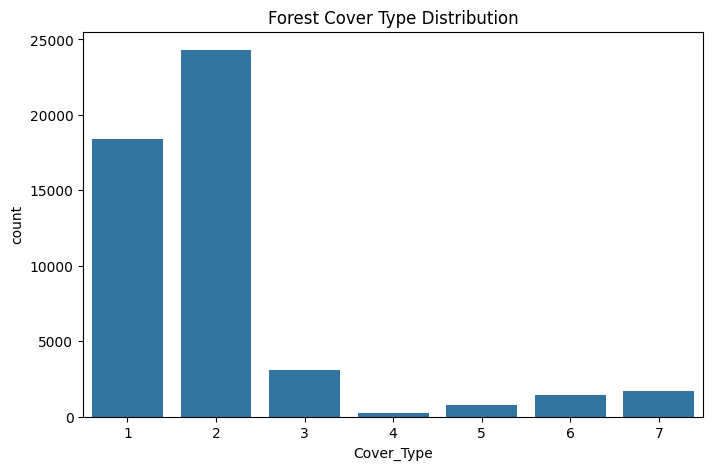

In [96]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Cover_Type",
    data=df
)

plt.title("Forest Cover Type Distribution")

plt.savefig(
    "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [97]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [98]:
Y_train = Y_train
Y_test = Y_test

In [99]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, Y_train)

rf_prediction = rf_model.predict(X_test)

In [100]:
accuracy = accuracy_score(Y_test, rf_prediction)
print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.8739


In [101]:
print(classification_report(Y_test, rf_prediction))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87      3626
           1       0.87      0.93      0.90      4894
           2       0.82      0.90      0.86       603
           3       0.78      0.70      0.74        46
           4       0.94      0.39      0.55       163
           5       0.80      0.61      0.69       313
           6       0.92      0.80      0.86       355

    accuracy                           0.87     10000
   macro avg       0.86      0.74      0.78     10000
weighted avg       0.87      0.87      0.87     10000



<Figure size 800x800 with 0 Axes>

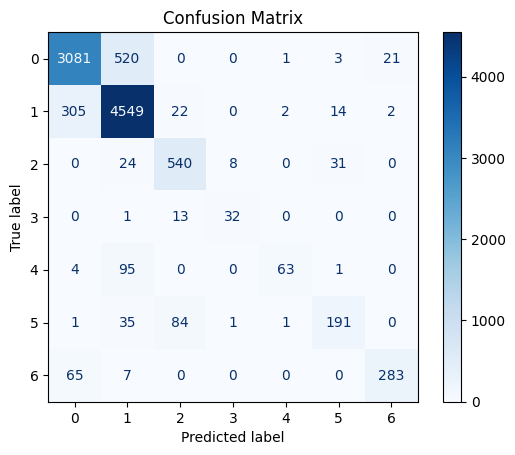

In [102]:
cm = confusion_matrix(
    Y_test,
    rf_prediction
)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [103]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

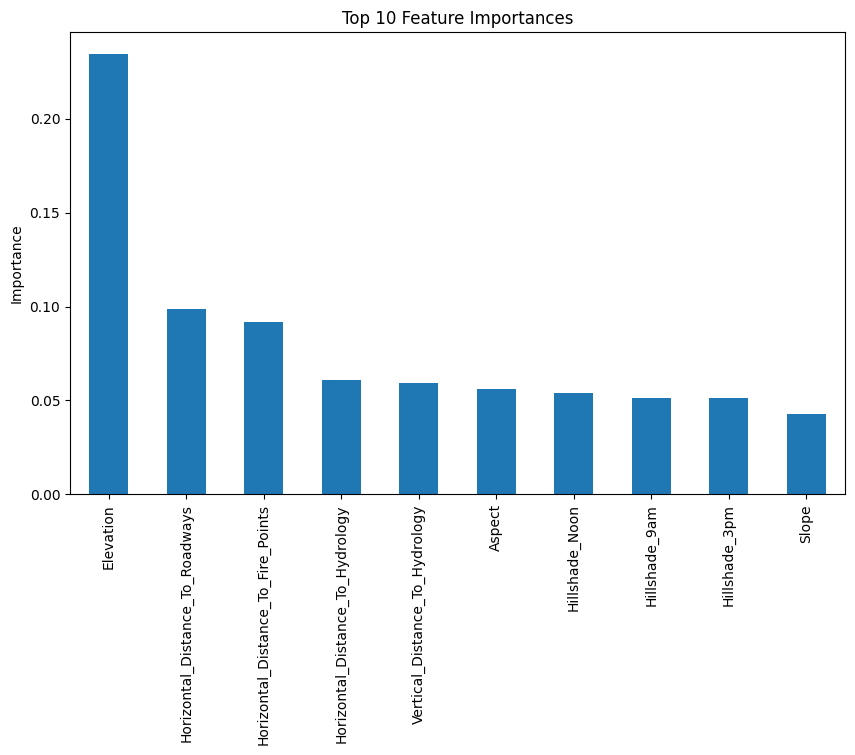

In [104]:
plt.figure(figsize=(10,6))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Feature Importances")

plt.ylabel("Importance")

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [105]:
!pip install xgboost

In [106]:
from xgboost import XGBClassifier

In [107]:
xgb_model = XGBClassifier(objective="multi:softmax", num_class=7, random=42)
xgb_model.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:27:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "random" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=7, ...)

In [108]:
xgb_prediction = xgb_model.predict(X_test)

In [109]:
print("XGBoost Accuracy:", accuracy_score(Y_test, xgb_prediction))

XGBoost Accuracy: 0.8489


In [110]:
print(classification_report(Y_test, xgb_prediction))

              precision    recall  f1-score   support

           0       0.85      0.82      0.84      3626
           1       0.85      0.89      0.87      4894
           2       0.84      0.85      0.84       603
           3       0.76      0.83      0.79        46
           4       0.86      0.44      0.58       163
           5       0.77      0.67      0.72       313
           6       0.94      0.82      0.87       355

    accuracy                           0.85     10000
   macro avg       0.84      0.76      0.79     10000
weighted avg       0.85      0.85      0.85     10000



In [111]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(Y_test, rf_prediction),
        accuracy_score(Y_test, xgb_prediction)
    ]
})

print(comparison)

           Model  Accuracy
0  Random Forest    0.8739
1        XGBoost    0.8489


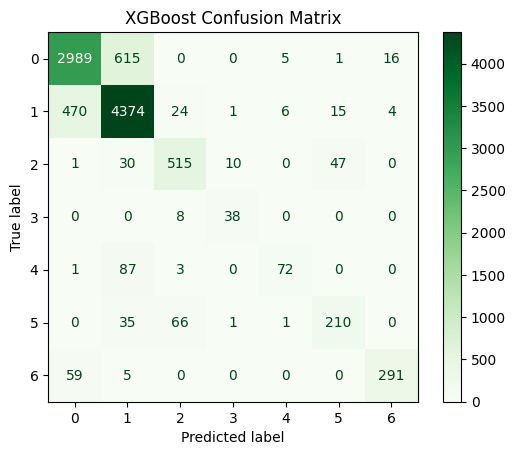

In [112]:
cm = confusion_matrix(
    Y_test,
    xgb_prediction
)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Greens")

plt.title("XGBoost Confusion Matrix")

plt.savefig(
    "xgboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [117]:
rf_accuracy = accuracy_score(
    Y_test,
    rf_prediction
)

xgb_accuracy = accuracy_score(
    Y_test,
    xgb_prediction
)

comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        rf_accuracy,
        xgb_accuracy
    ]

})

comparison

,Model,Accuracy
0,Random Forest,0.8739
1,XGBoost,0.8489


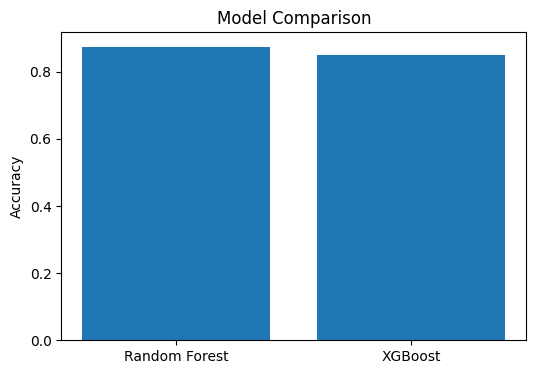

In [118]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Comparison")

plt.ylabel("Accuracy")

plt.savefig(
    "model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [119]:
from sklearn.model_selection import GridSearchCV

In [120]:
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5]
}

In [121]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, Y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [122]:
print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [123]:
print(grid.best_score_)

0.8587751648193485
